# Project — Chapter 85: Function Approximation

> **Prerequisites:** ch060 (Polynomials), ch072 (Fitting), ch073 (Residuals)
>
> **Concepts:** Taylor series, polynomial interpolation, Fourier approximation, error analysis
>
> **Output:** Compare multiple approximation methods on benchmark functions
>
> **Difficulty:** Intermediate | ~50 minutes

---

## Stage 1 — Taylor Polynomial Approximations

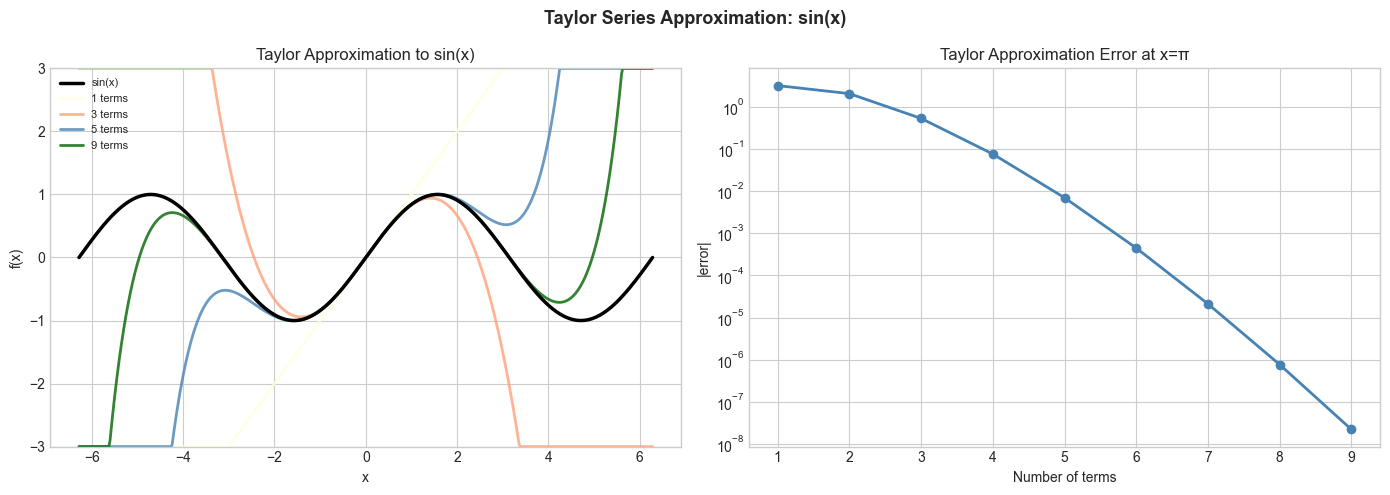

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def taylor_sin(x, n_terms):
    """Taylor series: sin(x) = Σ (-1)^k x^(2k+1) / (2k+1)!"""
    from math import factorial
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        result += (-1)**k * x**(2*k+1) / factorial(2*k+1)
    return result

x = np.linspace(-2*np.pi, 2*np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, np.sin(x), 'k-', linewidth=2.5, label='sin(x)', zorder=5)
for n, color in [(1,'lightyellow'),(2,'lightsalmon'),(3,'steelblue'),(5,'darkgreen')]:
    y_approx = taylor_sin(x, n)
    y_approx = np.clip(y_approx, -3, 3)
    axes[0].plot(x, y_approx, color=color, linewidth=2, alpha=0.8, label=f'{2*n-1} terms')
axes[0].set_ylim(-3, 3)
axes[0].set_title('Taylor Approximation to sin(x)'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

# Error vs n_terms at x=π
x_test = np.pi
errors = [abs(taylor_sin(np.array([x_test]), k)[0] - np.sin(x_test)) for k in range(1, 10)]
axes[1].semilogy(range(1, 10), errors, 'o-', color='steelblue', linewidth=2)
axes[1].set_title(f'Taylor Approximation Error at x=π'); axes[1].set_xlabel('Number of terms')
axes[1].set_ylabel('|error|')
plt.suptitle('Taylor Series Approximation: sin(x)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Chebyshev Polynomial Approximation

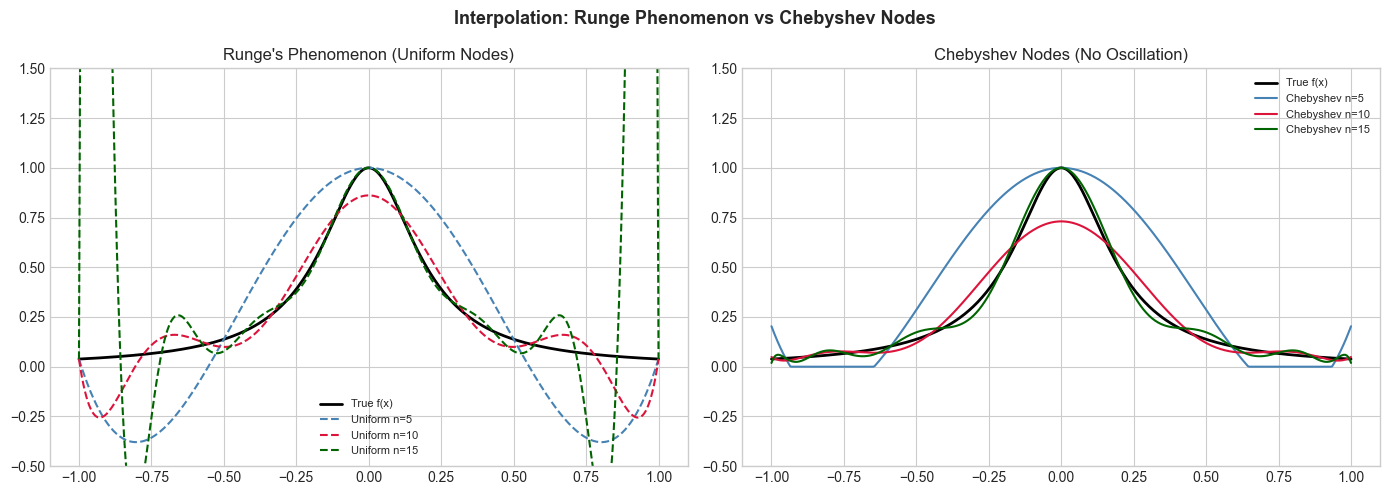

In [2]:
# Chebyshev approximation avoids Runge's phenomenon
# Nodes: xₖ = cos((2k+1)π/(2n)) for k=0,...,n-1

def chebyshev_nodes(n, a=-1, b=1):
    """Chebyshev nodes on [a, b]."""
    k = np.arange(n)
    nodes = np.cos((2*k + 1) * np.pi / (2*n))
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes

def lagrange_interp(x_nodes, y_nodes, x_query):
    """Lagrange interpolation."""
    result = np.zeros_like(x_query, dtype=float)
    n = len(x_nodes)
    for i in range(n):
        basis = np.ones_like(x_query, dtype=float)
        for j in range(n):
            if j != i:
                basis *= (x_query - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += y_nodes[i] * basis
    return result

# Runge function: notorious for Lagrange oscillations at uniform nodes
f_runge = lambda x: 1 / (1 + 25*x**2)
x_fine = np.linspace(-1, 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_fine, f_runge(x_fine), 'k-', linewidth=2, label='True f(x)')

for n, color in [(5,'steelblue'),(10,'crimson'),(15,'darkgreen')]:
    # Uniform nodes
    x_unif = np.linspace(-1, 1, n)
    y_unif = f_runge(x_unif)
    y_interp = lagrange_interp(x_unif, y_unif, x_fine)
    axes[0].plot(x_fine, np.clip(y_interp, -2, 2), color=color, linewidth=1.5, linestyle='--', label=f'Uniform n={n}')

axes[0].set_ylim(-0.5, 1.5); axes[0].set_title("Runge's Phenomenon (Uniform Nodes)"); axes[0].legend(fontsize=8)

axes[1].plot(x_fine, f_runge(x_fine), 'k-', linewidth=2, label='True f(x)')
for n, color in [(5,'steelblue'),(10,'crimson'),(15,'darkgreen')]:
    x_cheb = chebyshev_nodes(n)
    y_cheb = f_runge(x_cheb)
    y_interp = lagrange_interp(x_cheb, y_cheb, x_fine)
    axes[1].plot(x_fine, np.clip(y_interp, 0, 1.2), color=color, linewidth=1.5, label=f'Chebyshev n={n}')

axes[1].set_ylim(-0.5, 1.5); axes[1].set_title("Chebyshev Nodes (No Oscillation)"); axes[1].legend(fontsize=8)
plt.suptitle('Interpolation: Runge Phenomenon vs Chebyshev Nodes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 3 — Fourier Approximation

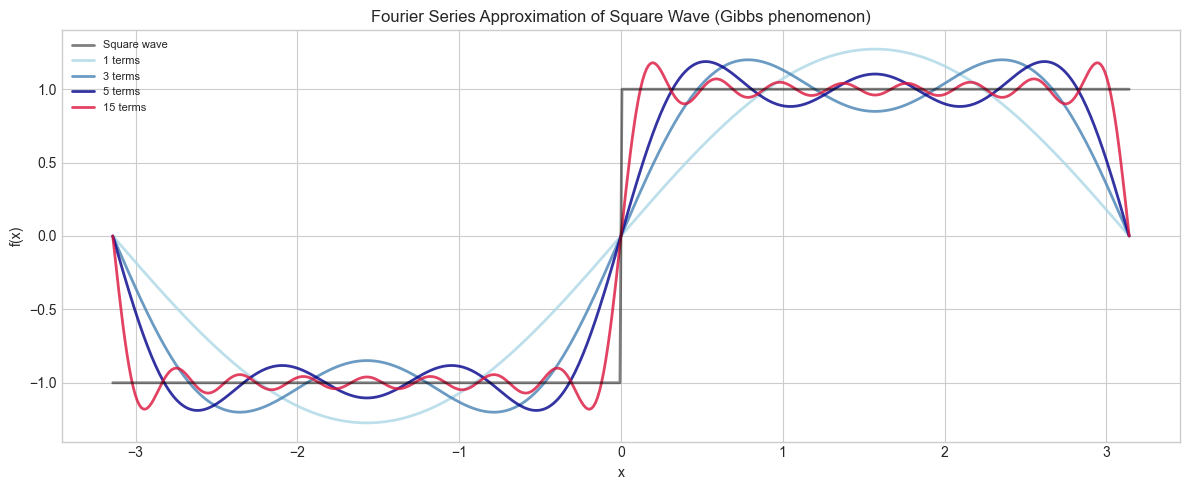

In [3]:
# Fourier series approximation of periodic functions
def fourier_approx(f, x, n_terms, period=2*np.pi):
    """Compute n_terms Fourier series approximation."""
    L = period / 2
    result = np.zeros_like(x, dtype=float)
    # Compute coefficients numerically
    x_quad = np.linspace(-L, L, 2000)
    dx = x_quad[1] - x_quad[0]
    a0 = np.sum(f(x_quad)) * dx / (2*L)
    result += a0
    for k in range(1, n_terms + 1):
        ak = np.sum(f(x_quad) * np.cos(k * np.pi * x_quad / L)) * dx / L
        bk = np.sum(f(x_quad) * np.sin(k * np.pi * x_quad / L)) * dx / L
        result += ak * np.cos(k * np.pi * x / L) + bk * np.sin(k * np.pi * x / L)
    return result

# Square wave
square_wave = lambda x: np.sign(np.sin(x))
x = np.linspace(-np.pi, np.pi, 500)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, square_wave(x), 'k-', linewidth=2, label='Square wave', zorder=5, alpha=0.5)
for n, color in [(1,'lightblue'),(3,'steelblue'),(5,'darkblue'),(15,'crimson')]:
    y_fourier = fourier_approx(square_wave, x, n)
    ax.plot(x, y_fourier, color=color, linewidth=2, alpha=0.8, label=f'{n} terms')
ax.set_title('Fourier Series Approximation of Square Wave (Gibbs phenomenon)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Taylor, Lagrange (uniform vs Chebyshev), and Fourier approximation methods applied to benchmark functions.

**Math used:** Taylor series (ch219), polynomial interpolation/Lagrange (ch060), Fourier series (previews Part VIII and signal processing).

**Extensions:** 1) Compare RMSE of all methods for fixed n. 2) Implement cubic spline interpolation. 3) Apply FFT to audio signal approximation.